<a href="https://colab.research.google.com/github/Erwin2Sibaja/challenge_2_telecom_x/blob/main/Telecom_X_An%C3%A1lisis_de_Evasi%C3%B3n_de_Clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracción

In [1]:
import pandas as pd

In [4]:
clientes = pd.read_json('/content/drive/MyDrive/Colab Notebooks/Challenge 2/TelecomX_Data.json')
clientes

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


## Diccionario e datos

*   **customerID**: número de identificación único de cada cliente
*   **Churn**: si el cliente dejó o no la empresa
*   **gender**: género (masculino y femenino)
*   **SeniorCitizen**: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
*   **Partner**: si el cliente tiene o no una pareja
*   **Dependents**: si el cliente tiene o no dependientes
*   **tenure**: meses de contrato del cliente
*   **PhoneService**: suscripción al servicio telefónico
*   **MultipleLines**: suscripción a más de una línea telefónica
*   **InternetService**: suscripción a un proveedor de internet
*   **OnlineSecurity**: suscripción adicional de seguridad en línea
*   **OnlineBackup**: suscripción adicional de respaldo en línea
*   **DeviceProtection**: suscripción adicional de protección del dispositivo
*   **TechSupport**: suscripción adicional de soporte técnico, menor tiempo de espera

*   **StreamingTV**: suscripción de televisión por cable
*   **StreamingMovies**: suscripción de streaming de películas
*   **Contract**: tipo de contrato
*   **PaperlessBilling**: si el cliente prefiere recibir la factura en línea
*   **PaymentMethod**: forma de pago
*   **Charges.Monthly**: total de todos los servicios del cliente por mes
*   **Charges.Total**: total gastado por el cliente

# Transformación

In [9]:
print(clientes['customer'].iloc[0])
print(clientes['phone'].iloc[0])
print(clientes['internet'].iloc[0])
print(clientes['account'].iloc[0])

{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}
{'PhoneService': 'Yes', 'MultipleLines': 'No'}
{'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'No'}
{'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}


In [10]:
columnas_dict = ['customer', 'phone', 'internet', 'account']

for col in columnas_dict:
    clientes[col] = clientes[col].apply(lambda x: x if isinstance(x, dict) else {})

In [16]:
df_customer = pd.json_normalize(clientes['customer'])
df_phone = pd.json_normalize(clientes['phone'])
df_internet = pd.json_normalize(clientes['internet'])

df_account = pd.json_normalize(clientes['account'])

clientes_final = pd.concat([
    clientes.drop(columns=columnas_dict),
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)


clientes_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [17]:
clientes_final['Charges.Total'] = pd.to_numeric(clientes_final['Charges.Total'], errors='coerce')
clientes_final

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [18]:
clientes_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#Carga y análisis

In [19]:
for col in clientes_final.select_dtypes(include='object').columns:
    print(f"Columna: {col}")
    print(clientes_final[col].unique())
    print("-" * 20)

Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
--------------------
Columna: Churn
['No' 'Yes' '']
--------------------
Columna: gender
['Female' 'Male']
--------------------
Columna: Partner
['Yes' 'No']
--------------------
Columna: Dependents
['Yes' 'No']
--------------------
Columna: PhoneService
['Yes' 'No']
--------------------
Columna: MultipleLines
['No' 'Yes' 'No phone service']
--------------------
Columna: InternetService
['DSL' 'Fiber optic' 'No']
--------------------
Columna: OnlineSecurity
['No' 'Yes' 'No internet service']
--------------------
Columna: OnlineBackup
['Yes' 'No' 'No internet service']
--------------------
Columna: DeviceProtection
['No' 'Yes' 'No internet service']
--------------------
Columna: TechSupport
['Yes' 'No' 'No internet service']
--------------------
Columna: StreamingTV
['Yes' 'No' 'No internet service']
--------------------
Columna: StreamingMovies
['No' 'Yes' 'No internet service']
---

In [20]:
clientes_final['Churn'] = clientes_final['Churn'].replace('', pd.NA)
columnas_a_limpiar = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in columnas_a_limpiar:
    clientes_final[col] = clientes_final[col].replace({
        'No phone service': 'No',
        'No internet service': 'No'
    })

for col in columnas_a_limpiar + ['Churn']:
    print(f"{col}: {clientes_final[col].unique()}")

MultipleLines: ['No' 'Yes']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['Yes' 'No']
StreamingTV: ['Yes' 'No']
StreamingMovies: ['No' 'Yes']
Churn: ['No' 'Yes' <NA>]


In [21]:
cols_dinero = ['Charges.Monthly', 'Charges.Total']

for col in cols_dinero:
    if col in clientes_final.columns:
        clientes_final[col] = clientes_final[col].astype(str).str.replace(',', '.')
        clientes_final[col] = pd.to_numeric(clientes_final[col], errors='coerce')

clientes_final[cols_dinero] = clientes_final[cols_dinero].fillna(clientes_final[cols_dinero].median())

In [23]:
clientes_final['Cuentas_Diarias'] = (clientes_final['Charges.Monthly'] / 30).round(2)
clientes_final

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.84
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


In [25]:
import numpy as np
mapeo = {'Yes': '1', 'No': '0'}
columnas_a_mapear = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

for col in columnas_a_mapear:
  if col in clientes_final.columns:
    clientes_final[col] = clientes_final[col].map(mapeo)
#Si es requerido cambiar el valor NA que esta en Churn
## clientes_final['Churn'] = clientes_final['Churn'].fillna(0)

clientes_final

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.84
7263,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.68
7265,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.26


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

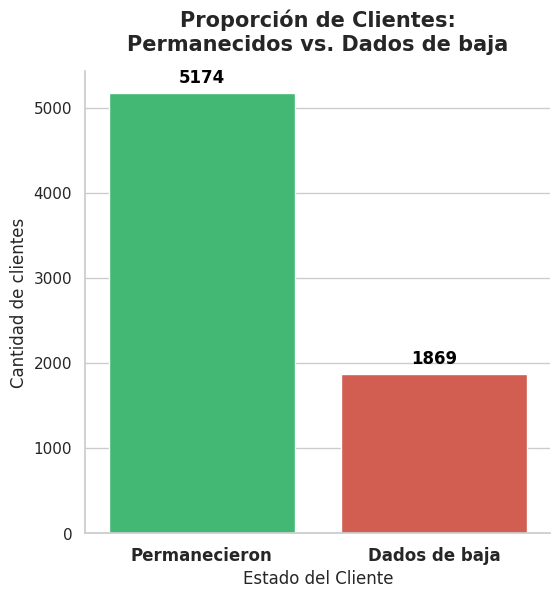

In [39]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,6))

ax = sns.countplot(
    data=clientes_final.dropna(subset=['Churn']),
    x='Churn',
    hue='Churn',
    palette=['#2ecc71', '#e74c3c'],
    legend=False
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Permanecieron', 'Dados de baja'], fontsize=12, fontweight='bold')
plt.title('Proporción de Clientes:\nPermanecidos vs. Dados de baja', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad de clientes', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

sns.despine()

plt.show()

# Informe final